In [4]:
import argparse
import csv
import json
import sys
import time
import shlex
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

src_dir = str(Path.cwd().parent / 'src')
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

from sqli_sandbox import ASTProfile, SQLiSandbox

In [5]:
def parse_args(args_string=""):
    p = argparse.ArgumentParser()
    p.add_argument("csv_path", nargs="?", default="SQL_injection_Dataset_Feature_Extraction_Results.csv")
    p.add_argument("--limit", type=int, default=None, help="Only evaluate first N rows")
    p.add_argument("--show-fp", action="store_true", help="Print false positive samples")
    p.add_argument("--show-fn", action="store_true", help="Print false negative samples")
    p.add_argument("--sample", type=int, default=20, help="Max FP/FN samples to show (default 20)")
    
    return p.parse_args(shlex.split(args_string))


def load_profiles(profile_path):
    profiles = {}

    def safe_json(value, default):
        try:
            parsed = json.loads(value or "null")
            return parsed if parsed is not None else default
        except Exception:
            return default

    def safe_int(value, default):
        try:
            return int(float(value))
        except (TypeError, ValueError):
            return default

    with open(profile_path, newline="", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f)
        for row in reader:
            query = row.get("Query", "")
            if not query:
                continue

            is_valid = row.get("is_valid_syntax", "False").strip().lower() == "true"

            profiles[query] = ASTProfile(
                is_valid=is_valid,
                winning_context_index=safe_int(row.get("winning_context_index"), -1),
                winning_dialect=row.get("winning_dialect") or None,
                tables=safe_json(row.get("tables"), []),
                columns=safe_json(row.get("columns"), []),
                literal_types=safe_json(row.get("literal_types"), []),
                select_arm_widths=safe_json(row.get("select_arm_widths"), []),
                node_set=set(safe_json(row.get("node_set"), [])),
            )

    return profiles


def bar(value, width=30):
    filled = round(value * width)
    return "█" * filled + "░" * (width - filled)


def run_sandbox_test(args_string=""):
    args = parse_args(args_string)
    profile_path = Path(args.csv_path)

    if not profile_path.exists():
        print(f"ERROR: CSV not found at '{profile_path}'")
        return

    try:
        profiles = load_profiles(profile_path)
    except Exception as exc:
        print(f"ERROR: could not load CSV ({exc}).")
        return

    with open(profile_path, newline="", encoding="utf-8-sig") as f:
        all_rows = list(csv.DictReader(f))

    rows  = all_rows[: args.limit] if args.limit else all_rows
    total = len(rows)
    if total == 0:
        print("ERROR: Dataset is empty.")
        return
        
    n_mal = sum(1 for r in rows if int(r["Label"]) == 1)
    n_ben = total - n_mal

    W = 60
    print(f"\n{'═'*W}")
    print(f"  Dataset : {profile_path.name}")
    print(f"  Rows    : {total:,}" + (f"  (of {len(all_rows):,})" if args.limit else ""))
    print(f"  Classes : {n_mal:,} malicious  |  {n_ben:,} benign")
    print(f"{'═'*W}\n")

    sb = SQLiSandbox()
    TP = TN = FP = FN = 0
    executed_count = static_count = 0
    executed_mal = executed_ben = 0
    static_mal = static_ben = 0
    ex_TP = ex_TN = ex_FP = ex_FN = 0
    st_TP = st_TN = st_FP = st_FN = 0
    
    unknown_count = 0
    exploit_counts = Counter()
    fp_rows, fn_rows = [], []

    print("Running", end="", flush=True)
    t0   = time.time()
    tick = max(1, total // 20)

    for i, row in enumerate(rows):
        query  = row["Query"]
        label  = int(row["Label"])
        
        profile = profiles.get(query)
                
        result = sb.test(query, profile)
        pred   = 1 if result.malicious else 0

        if label == 1 and pred == 1: 
            TP += 1
            exploit_counts[result.exploit_type or "none"] += 1
            if result.exploit_type == "unknown_injection":
                unknown_count += 1
        elif label == 0 and pred == 0: 
            TN += 1
        elif label == 0 and pred == 1: 
            FP += 1
            fp_rows.append((query, result.exploit_type or "none", result.detection_reason))
        else:                          
            FN += 1
            fn_rows.append((query, result.exploit_type or "none", result.detection_reason))

        if result.executed:
            executed_count += 1
            executed_mal += int(result.malicious)
            executed_ben += int(not result.malicious)
            if label == 1 and pred == 1:
                ex_TP += 1
            elif label == 0 and pred == 0:
                ex_TN += 1
            elif label == 0 and pred == 1:
                ex_FP += 1
            else:
                ex_FN += 1
        else:
            static_count += 1
            static_mal += int(result.malicious)
            static_ben += int(not result.malicious)
            if label == 1 and pred == 1:
                st_TP += 1
            elif label == 0 and pred == 0:
                st_TN += 1
            elif label == 0 and pred == 1:
                st_FP += 1
            else:
                st_FN += 1

        if (i + 1) % tick == 0:
            print(".", end="", flush=True)

    elapsed = time.time() - t0
    print(f" done ({elapsed:.1f}s, {total / elapsed:.0f} q/s)\n")

    def path_metrics(tp, tn, fp, fn):
        n = tp + tn + fp + fn
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
        acc = (tp + tn) / n if n else 0.0
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        return prec, rec, f1, acc, fpr


    ex_prec, ex_rec, ex_f1, ex_acc, ex_fpr = path_metrics(ex_TP, ex_TN, ex_FP, ex_FN)
    st_prec, st_rec, st_f1, st_acc, st_fpr = path_metrics(st_TP, st_TN, st_FP, st_FN)

    print("─" * W)
    print(f"  SANDBOX EXECUTION PATH  ({executed_count:,} queries)")
    print("─" * W)
    print(f"  {'Accuracy':<22} {ex_acc:.4f}")
    print(f"  {'Precision':<22} {ex_prec:.4f}")
    print(f"  {'Recall':<22} {ex_rec:.4f}")
    print(f"  {'F1':<22} {ex_f1:.4f}")
    print(f"  {'False Positive Rate':<22} {ex_fpr:.4f}")
    print(f"  TP={ex_TP:,}  FP={ex_FP:,}  TN={ex_TN:,}  FN={ex_FN:,}")
    print(f"  Predicted malicious : {executed_mal:,}  |  Predicted benign : {executed_ben:,}")
    print("─" * W)
    print(f"  STATIC FILTER PATH  ({static_count:,} queries)")
    print("─" * W)
    print(f"  {'Accuracy':<22} {st_acc:.4f}")
    print(f"  {'Precision':<22} {st_prec:.4f}")
    print(f"  {'Recall':<22} {st_rec:.4f}")
    print(f"  {'F1':<22} {st_f1:.4f}")
    print(f"  {'False Positive Rate':<22} {st_fpr:.4f}")
    print(f"  TP={st_TP:,}  FP={st_FP:,}  TN={st_TN:,}  FN={st_FN:,}")
    print(f"  Predicted malicious : {static_mal:,}  |  Predicted benign : {static_ben:,}")
    print()

    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall = TP / (TP + FN) if (TP + FN) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    accuracy = (TP + TN) / total
    specificity = TN / (TN + FP) if (TN + FP) else 0.0
    fpr = FP / (FP + TN) if (FP + TN) else 0.0

    print("═" * W)
    print("  PERFORMANCE METRICS")
    print("─" * W)
    print(f"  {'Accuracy':<22} {accuracy:.4f}  {bar(accuracy)}")
    print(f"  {'Precision (PPV)':<22} {precision:.4f}  {bar(precision)}")
    print(f"  {'Recall (Sensitivity)':<22} {recall:.4f}  {bar(recall)}")
    print(f"  {'Specificity (TNR)':<22} {specificity:.4f}  {bar(specificity)}")
    print(f"  {'F1 Score':<22} {f1:.4f}  {bar(f1)}")
    print(f"  {'False Positive Rate':<22} {fpr:.4f}  {bar(fpr)}")
    print("─" * W)
    print("  CONFUSION MATRIX")
    print(f"                     Predicted")
    print(f"                  Malicious  Benign")
    print(f"  Actual Malicious  {TP:>7,}  {FN:>6,}   (detection rate: {recall * 100:.1f}%)")
    print(f"  Actual Benign     {FP:>7,}  {TN:>6,}   (false alarm rate: {fpr * 100:.1f}%)")
    print("═" * W)

    print("\n  DETECTION BREAKDOWN  (true positives only)")
    print("─" * W)
    for exploit, count in exploit_counts.most_common():
        pct = count / TP * 100 if TP else 0
        marker = "  ← unknown, needs review" if exploit == "unknown_injection" else ""
        print(f"  {exploit:<34} {count:>5,}  ({pct:.1f}%){marker}")
    print("═" * W)

    if args.show_fp and fp_rows:
        print(f"\n  FALSE POSITIVES ({FP:,}) - benign queries flagged as malicious")
        print("─" * W)
        fp_by_type = Counter(etype for _, etype, _ in fp_rows)
        print("  Breakdown by detected type (filter causing the FP):")
        for etype, cnt in fp_by_type.most_common():
            print(f"    {etype:<34} {cnt:>5,}")
        print()
        fp_by_reason = Counter(reason[:60] for _, _, reason in fp_rows)
        print("  Breakdown by detection reason:")
        for reason, cnt in fp_by_reason.most_common(8):
            print(f"    [{cnt:>4}]  {reason}")
        print(f"\n  Sample (first {min(args.sample, len(fp_rows))}):")
        for q, etype, reason in fp_rows[: args.sample]:
            print(f"    {repr(q[:70])}")
            print(f"         type   → {etype}")
            print(f"         reason → {reason[:65]}")

    if args.show_fn and fn_rows:
        print(f"\n  FALSE NEGATIVES ({FN:,}) - malicious queries missed by sandbox")
        print("─" * W)
        print(f"\n  Sample (first {min(args.sample, len(fn_rows))}):")
        for q, etype, reason in fn_rows[: args.sample]:
            print(f"    {repr(q[:70])}")
            print(f"         reason → {reason[:65]}")

    print(
        f"\n  Accuracy={accuracy * 100:.2f}%  F1={f1:.4f}  "
        f"Precision={precision:.4f}  Recall={recall:.4f}  FPR={fpr:.4f}"
    )
    print(f"  TP={TP:,}  FP={FP:,}  TN={TN:,}  FN={FN:,}\n")

    # ==========================================
    # VISUALIZATIONS
    # ==========================================
    
    sns.set_palette("muted")
    plt.style.use('seaborn-v0_8-whitegrid')

    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    
    labels = ['Malicious', 'Benign']

    # Confusion matrix (overall + combined)
    cm_combined = np.array([[TP, FN], [FP, TN]])
    sns.heatmap(cm_combined, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 14}, ax=axes[0,0])
    axes[0,0].set_title('Confusion Matrix (Overall)', fontsize=16, pad=15)
    axes[0,0].set_ylabel('Actual Label', fontsize=12)
    axes[0,0].set_xlabel('Predicted Label', fontsize=12)

    # Overall performance metrics
    metrics = {
        'Accuracy': accuracy, 
        'Precision': precision, 
        'Recall': recall, 
        'F1 Score': f1, 
    }
    bars1 = axes[0,1].bar(list(metrics.keys()), list(metrics.values()), color='#4C72B0')
    axes[0,1].set_title('Overall Performance Metrics', fontsize=16, pad=15)
    
    min_metric = min(metrics.values()) if metrics else 0
    axes[0,1].set_ylim(max(0, min_metric - 0.05), 1) 
    
    for bar_ in bars1:
        yval = bar_.get_height()
        axes[0,1].text(bar_.get_x() + bar_.get_width()/2, yval + 0.002, f'{yval:.4f}', ha='center', va='bottom', fontsize=11)

    # Confusion matrix (sandbox execution path)
    cm_ex = np.array([[ex_TP, ex_FN], [ex_FP, ex_TN]])
    sns.heatmap(cm_ex, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels, annot_kws={"size": 14}, ax=axes[1,0])
    axes[1,0].set_title(f'Confusion Matrix (Sandbox: {executed_count:,} queries)', fontsize=16, pad=15)
    axes[1,0].set_ylabel('Actual Label', fontsize=12)
    axes[1,0].set_xlabel('Predicted Label', fontsize=12)

    # Confusion matrix (static filter path)
    cm_st = np.array([[st_TP, st_FN], [st_FP, st_TN]])
    sns.heatmap(cm_st, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels, annot_kws={"size": 14}, ax=axes[1,1])
    axes[1,1].set_title(f'Confusion Matrix (Static Filter: {static_count:,} queries)', fontsize=16, pad=15)
    axes[1,1].set_ylabel('Actual Label', fontsize=12)
    axes[1,1].set_xlabel('Predicted Label', fontsize=12)

    # Path comparison (sandbox vs static filter)
    path_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    sandbox_vals = [ex_acc, ex_prec, ex_rec, ex_f1]
    static_vals  = [st_acc, st_prec, st_rec, st_f1]
    
    x = np.arange(len(path_labels))
    width = 0.35
    
    rects1 = axes[2,0].bar(x - width/2, sandbox_vals, width, label='Sandbox', color='#C44E52')
    rects2 = axes[2,0].bar(x + width/2, static_vals, width, label='Static Filter', color='#8172B3')
    
    axes[2,0].set_ylabel('Scores', fontsize=12)
    axes[2,0].set_title('Sandbox vs. Static Filter Performance', fontsize=16, pad=15)
    axes[2,0].set_xticks(x)
    axes[2,0].set_xticklabels(path_labels, fontsize=12)
    
    min_path_val = min(min(sandbox_vals), min(static_vals)) if sandbox_vals and static_vals else 0
    axes[2,0].set_ylim(max(0, min_path_val - 0.05), 1)
    axes[2,0].legend(loc='lower right', fontsize=11)
    
    def autolabel(rects, ax):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10)
    
    autolabel(rects1, axes[2,0])
    autolabel(rects2, axes[2,0])

    # Detection breakdown
    if exploit_counts:
        sorted_breakdown = dict(sorted(exploit_counts.items(), key=lambda item: item[1]))
        bars2 = axes[2,1].barh(list(sorted_breakdown.keys()), list(sorted_breakdown.values()), color='#55A868')
        axes[2,1].set_title('Detection Breakdown (True Positives)', fontsize=16, pad=15)
        axes[2,1].set_xlabel('Number of Queries Detected', fontsize=12)
        
        max_val = max(exploit_counts.values()) if exploit_counts else 1
        for bar_ in bars2:
            axes[2,1].text(bar_.get_width() + (max_val * 0.02), 
                           bar_.get_y() + bar_.get_height()/2, 
                           f'{int(bar_.get_width()):,}', 
                           va='center', ha='left', fontsize=10)
        axes[2,1].set_xlim(0, max_val * 1.2)
    else:
        axes[2,1].text(0.5, 0.5, "No detections to display", ha='center', va='center')
        axes[2,1].set_title('Detection Breakdown (True Positives)', fontsize=16, pad=15)

    plt.tight_layout()
    plt.show()

In [11]:
dataset1 = 'SQL_injection_Dataset'
dataset2 = 'clean_sql_dataset'
CLI1 = f"'{dataset1}_features.csv'"
CLI2 = f"'{dataset2}_features.csv'"




════════════════════════════════════════════════════════════
  Dataset : SQL_injection_Dataset_features.csv
  Rows    : 30,919
  Classes : 11,382 malicious  |  19,537 benign
════════════════════════════════════════════════════════════

Running.................... done (503.5s, 61 q/s)

────────────────────────────────────────────────────────────
  SANDBOX EXECUTION PATH  (27,525 queries)
────────────────────────────────────────────────────────────
  Accuracy               0.9954
  Precision              0.9985
  Recall                 0.9863
  F1                     0.9924
  False Positive Rate    0.0006
  TP=8,194  FP=12  TN=19,205  FN=114
  Predicted malicious : 8,206  |  Predicted benign : 19,319
────────────────────────────────────────────────────────────
  STATIC FILTER PATH  (3,394 queries)
────────────────────────────────────────────────────────────
  Accuracy               0.9976
  Precision              1.0000
  Recall                 0.9974
  F1                     0.9987
  

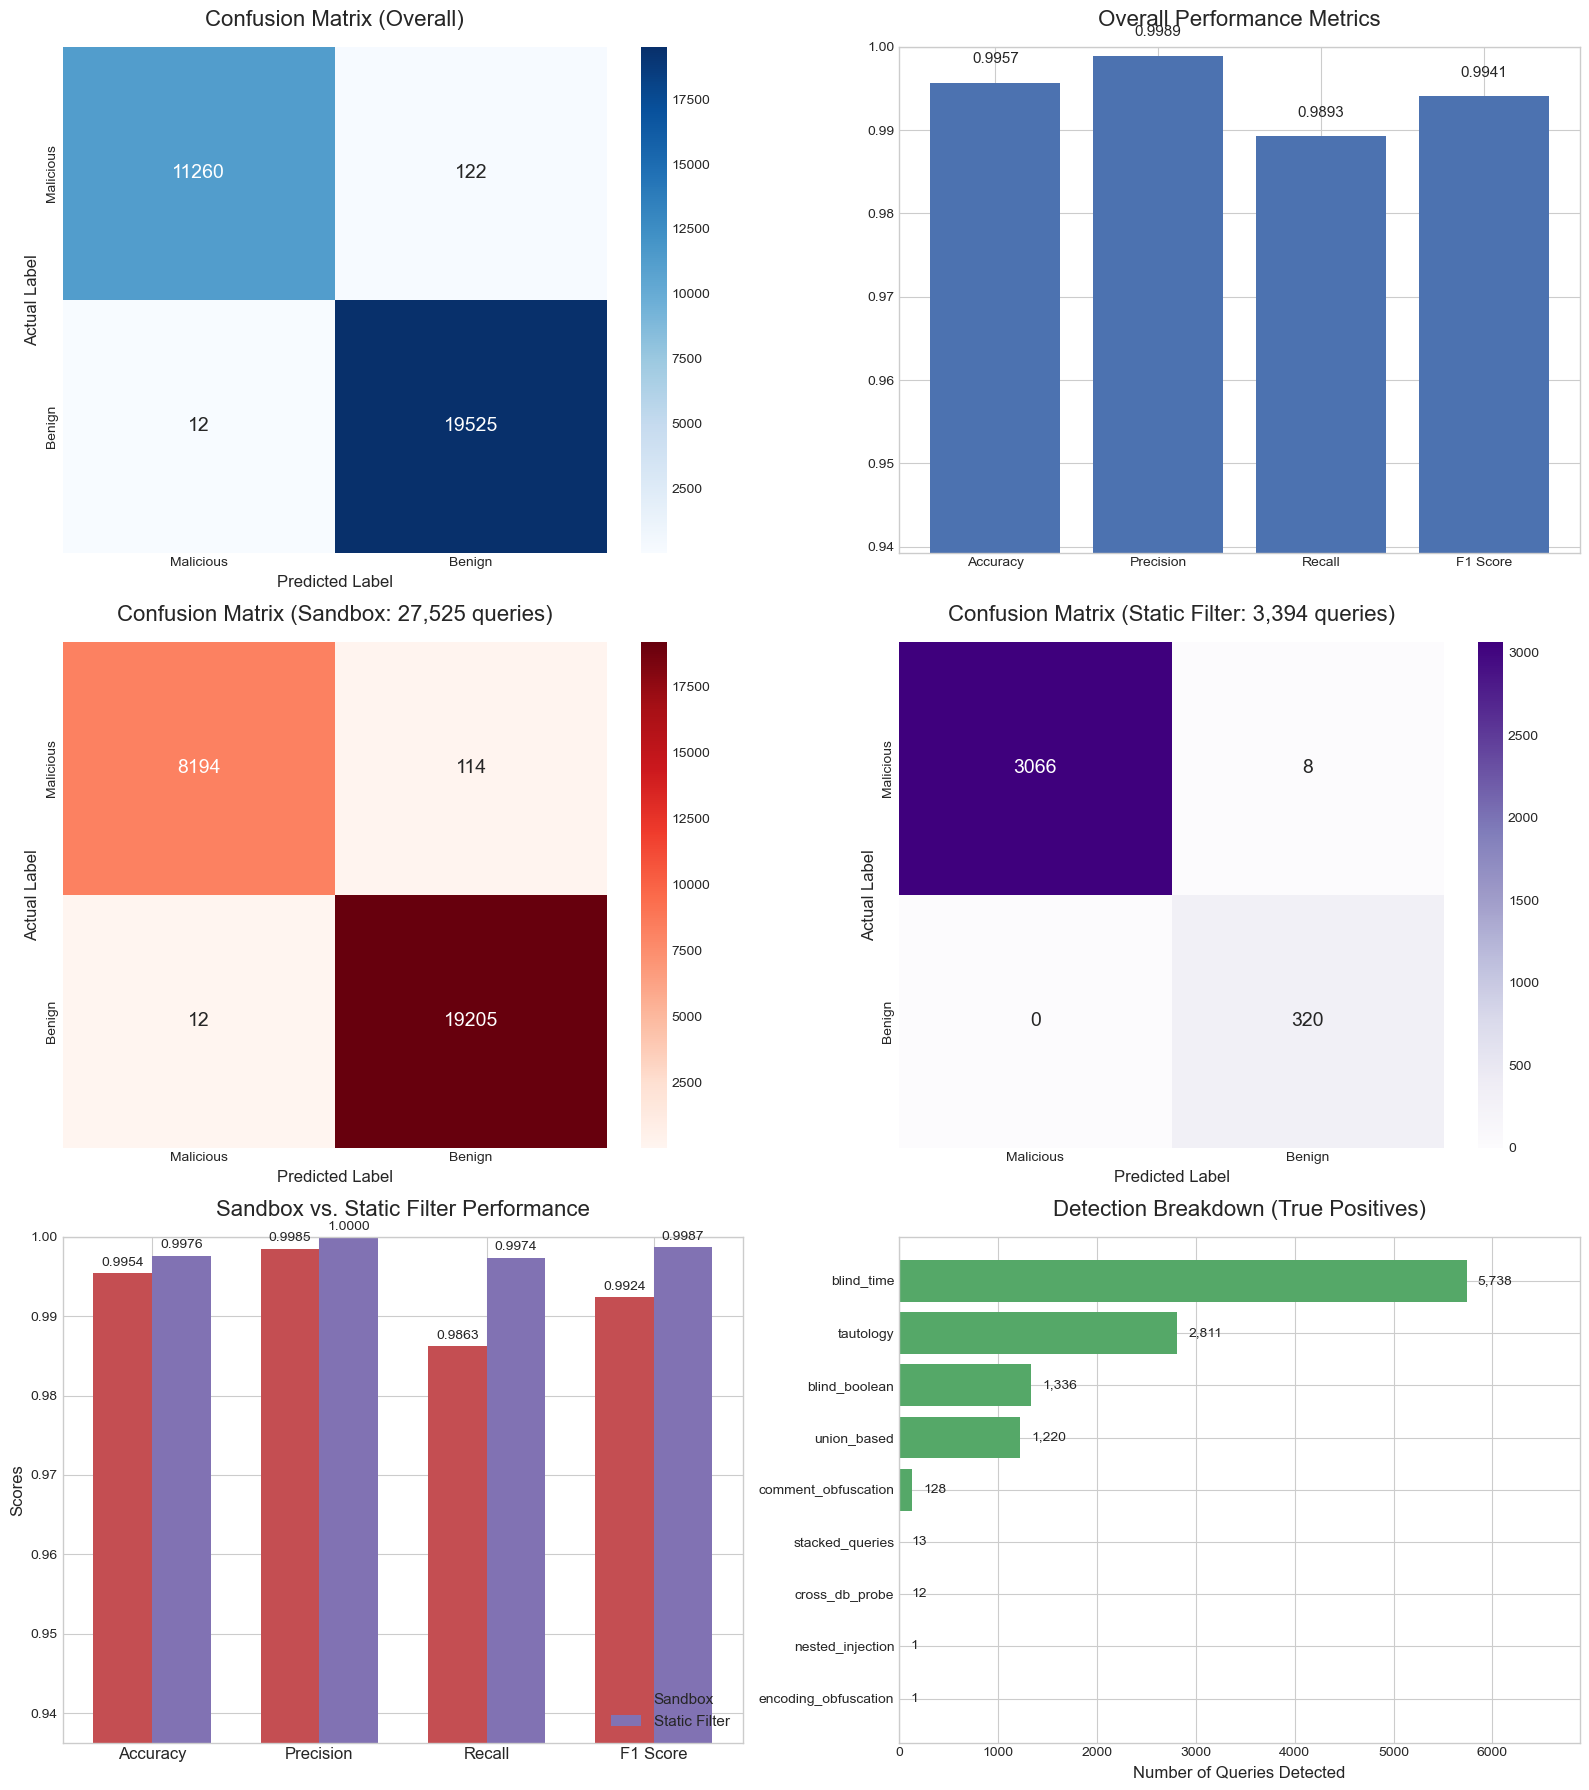


════════════════════════════════════════════════════════════
  Dataset : clean_sql_dataset_features.csv
  Rows    : 148,326
  Classes : 77,750 malicious  |  70,576 benign
════════════════════════════════════════════════════════════

Running.................... done (2721.1s, 55 q/s)

────────────────────────────────────────────────────────────
  SANDBOX EXECUTION PATH  (85,800 queries)
────────────────────────────────────────────────────────────
  Accuracy               0.9781
  Precision              0.9988
  Recall                 0.9626
  F1                     0.9803
  False Positive Rate    0.0016
  TP=46,812  FP=58  TN=37,109  FN=1,821
  Predicted malicious : 46,870  |  Predicted benign : 38,930
────────────────────────────────────────────────────────────
  STATIC FILTER PATH  (62,526 queries)
────────────────────────────────────────────────────────────
  Accuracy               0.9843
  Precision              0.9942
  Recall                 0.9720
  F1                     0.9830

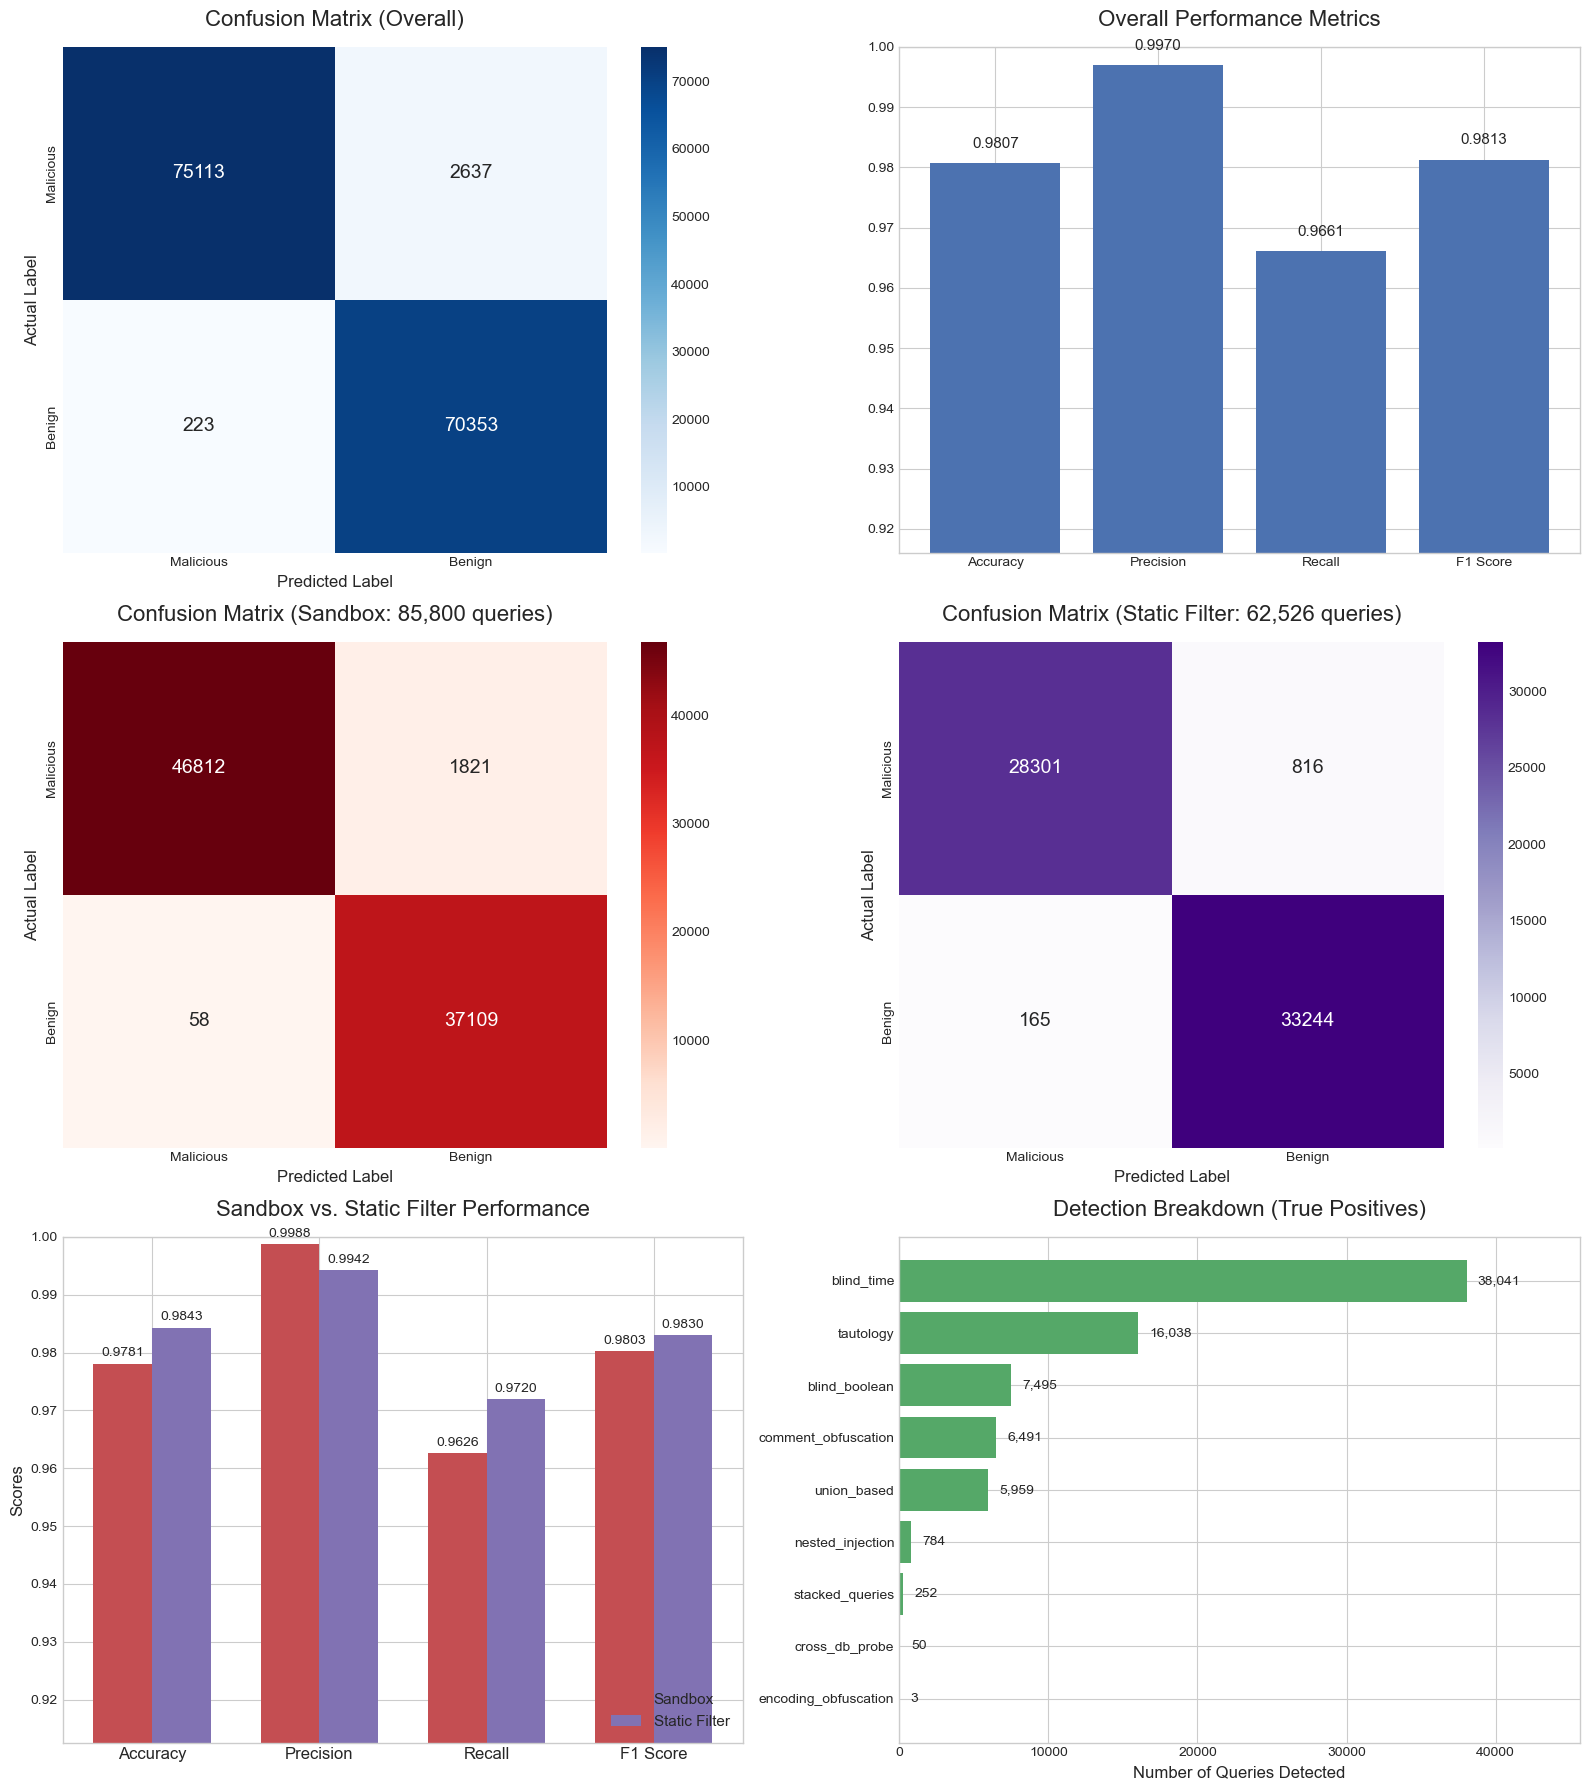

In [12]:
# Run the test and display output + charts
run_sandbox_test(CLI1)
run_sandbox_test(CLI2)